In [1]:
pip install pandas matplotlib seaborn psycopg2


   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 23.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 6.8 MB/s eta 0:00:00


In [11]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    database="ecommerce_db",
    user="postgres",
    password="Dharmateja@2002"
)
print("Connected")

Connected


C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\3835210673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


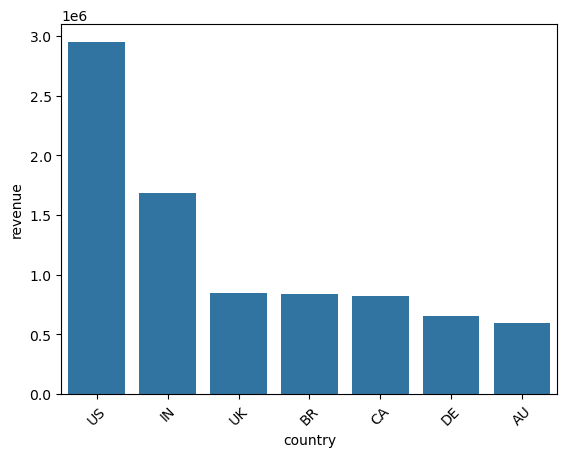

In [12]:
# 1. Revenue by Country (Geographic Insight)
query = """
SELECT 
    c.country,
    SUM(t.gross_revenue::NUMERIC) AS revenue
FROM transactions t
JOIN customers c 
    ON t.customer_id = c.customer_id
GROUP BY c.country
ORDER BY revenue DESC;
"""

df = pd.read_sql(query, conn)

sns.barplot(data=df, x='country', y='revenue')
plt.xticks(rotation=45)
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\868843515.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


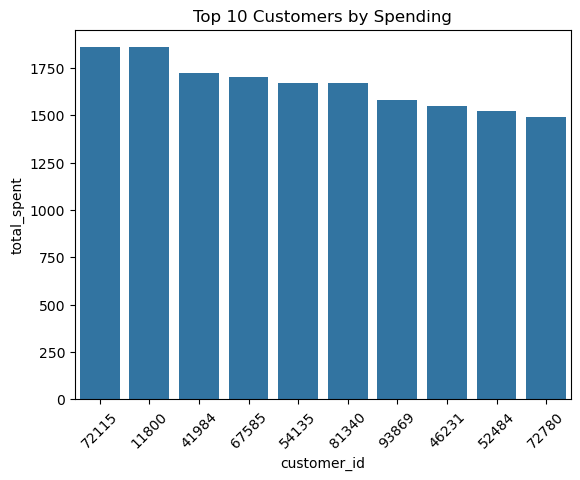

In [13]:
# 2. Top 10 Customers (High-Value Users)
query = """
SELECT 
    customer_id,
    SUM(gross_revenue::NUMERIC) AS total_spent
FROM transactions
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

sns.barplot(data=df, x='customer_id', y='total_spent')
plt.title("Top 10 Customers by Spending")
plt.xticks(rotation=45)
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\1426372766.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


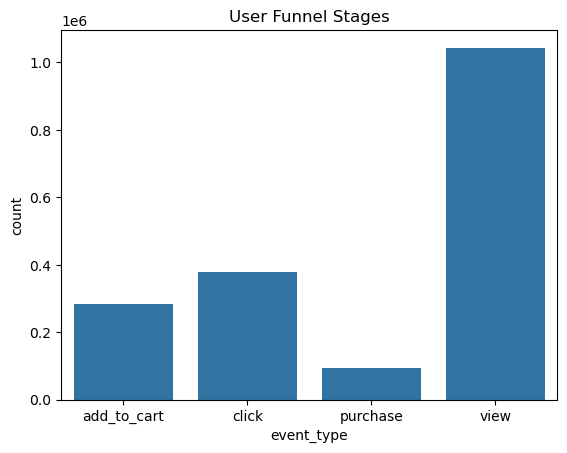

In [14]:
#3. Event Funnel
query = """
SELECT
    event_type,
    COUNT(*) AS count
FROM events
GROUP BY event_type;
"""

df = pd.read_sql(query, conn)

sns.barplot(data=df, x='event_type', y='count')
plt.title("User Funnel Stages")
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\1947731371.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


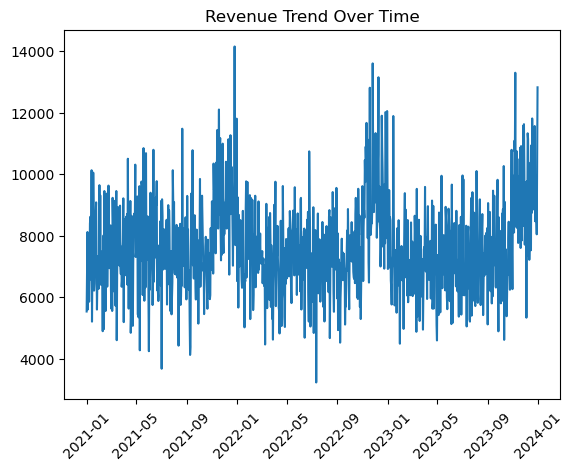

In [15]:
# 4. Revenue Trend Over Time

query = """
SELECT 
    DATE(transaction_time) AS date,
    SUM(gross_revenue::NUMERIC) AS revenue
FROM transactions
GROUP BY date
ORDER BY date;
"""

df = pd.read_sql(query, conn)

plt.plot(df['date'], df['revenue'])
plt.title("Revenue Trend Over Time")
plt.xticks(rotation=45)
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\1483113254.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


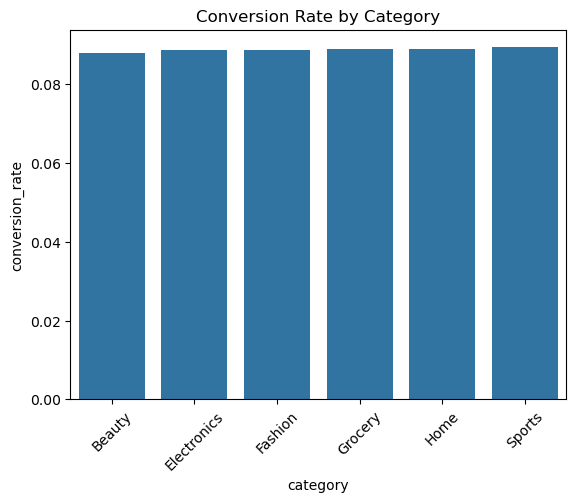

In [16]:
# 5. Category vs Conversion Rate
query = """
SELECT 
    p.category,
    COUNT(*) FILTER (WHERE e.event_type = 'view') AS views,
    COUNT(*) FILTER (WHERE e.event_type = 'purchase') AS purchases
FROM events e
JOIN products p 
    ON e.product_id::FLOAT::INT = p.product_id::INT
GROUP BY p.category;
"""

df = pd.read_sql(query, conn)

df['conversion_rate'] = df['purchases'] / df['views']

sns.barplot(data=df, x='category', y='conversion_rate')
plt.title("Conversion Rate by Category")
plt.xticks(rotation=45)
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\3863016949.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


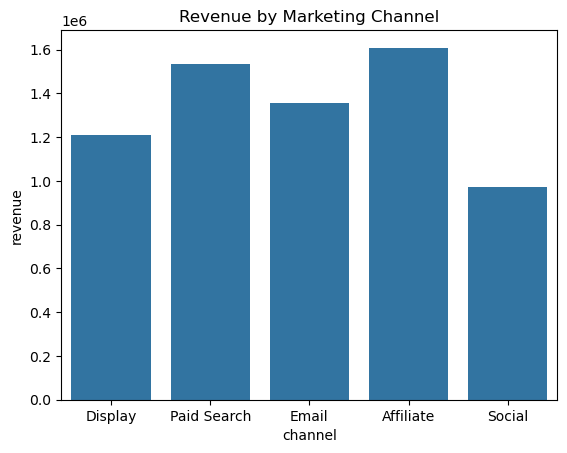

In [17]:
# 6. Campaign Channel Performance
query = """
SELECT 
    c.channel,
    SUM(t.gross_revenue::NUMERIC) AS revenue
FROM transactions t
JOIN campaigns c 
    ON t.campaign_id = c.campaign_id
GROUP BY c.channel;
"""

df = pd.read_sql(query, conn)

sns.barplot(data=df, x='channel', y='revenue')
plt.title("Revenue by Marketing Channel")
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\2432812448.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


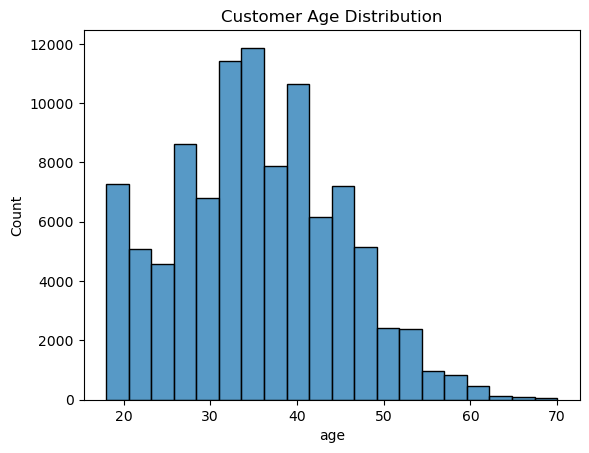

In [18]:
#7. Customer Age Distribution

query = """
SELECT age FROM customers;
"""

df = pd.read_sql(query, conn)

sns.histplot(df['age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\2400092565.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


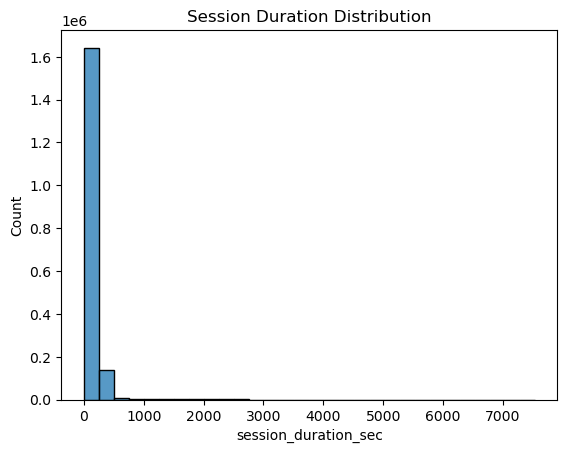

In [19]:
# 8. Session Duration vs Engagement

query = """
SELECT session_duration_sec FROM events;
"""

df = pd.read_sql(query, conn)

sns.histplot(df['session_duration_sec'], bins=30)
plt.title("Session Duration Distribution")
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\291250566.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


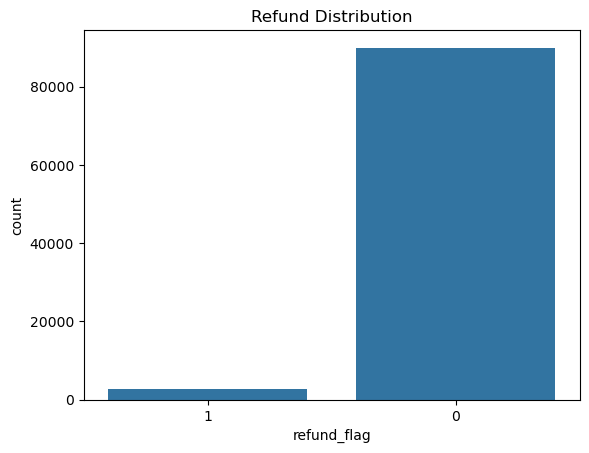

In [20]:
# 9. Refund Analysis

query = """
SELECT refund_flag, COUNT(*) as count
FROM transactions
GROUP BY refund_flag;
"""

df = pd.read_sql(query, conn)

sns.barplot(data=df, x='refund_flag', y='count')
plt.title("Refund Distribution")
plt.show()

C:\Users\dharm\AppData\Local\Temp\ipykernel_24148\3042085197.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


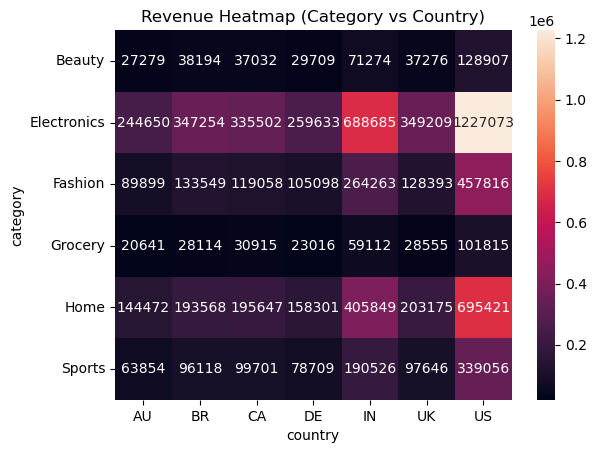

In [21]:
# 10. Heat Map
query = """
SELECT 
    p.category,
    c.country,
    SUM(t.gross_revenue::NUMERIC) AS revenue
FROM transactions t
JOIN products p ON t.product_id::INT = p.product_id::INT
JOIN customers c ON t.customer_id = c.customer_id
GROUP BY p.category, c.country;
"""

df = pd.read_sql(query, conn)

pivot = df.pivot(index='category', columns='country', values='revenue')

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Revenue Heatmap (Category vs Country)")
plt.show()